In [117]:
# On importe toutes les librairies dont on a besoin
import pandas as pd          # Pour manipuler les données (tableaux)
import numpy as np           # Pour les calculs mathématiques
import matplotlib.pyplot as plt  # Pour faire des graphiques
import seaborn as sns        # Pour faire des graphiques plus jolis

# On dit à matplotlib d'afficher les graphiques directement dans le notebook
%matplotlib inline

# On configure le style des graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librairies importées avec succès !")

✅ Librairies importées avec succès !


In [ ]:
# On charge le fichier CSV dans un "DataFrame"
df = pd.read_csv("../data/customer_churn_business_dataset.csv")

# On affiche les 5 premières lignes pour voir à quoi ressemblent les données
print("✅ Dataset chargé !")
print(f"📊 Nombre de clients : {df.shape[0]}")
print(f"📋 Nombre de colonnes : {df.shape[1]}")
print("\n--- Les 5 premières lignes ---")
df.head()

✅ Dataset chargé !
📊 Nombre de clients : 10000
📋 Nombre de colonnes : 32

--- Les 5 premières lignes ---


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [119]:
# .info() nous donne des infos importantes sur chaque colonne :
# - Le nom de la colonne
# - Le nombre de valeurs non nulles (pour détecter les valeurs manquantes)
# - Le type de données (int, float, object...)
print("=== INFORMATIONS GÉNÉRALES ===")
df.info()

=== INFORMATIONS GÉNÉRALES ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago

In [120]:
# .describe() nous donne les statistiques de base pour chaque colonne numérique :
# - count : nombre de valeurs
# - mean : la moyenne
# - std : l'écart-type (est-ce que les valeurs sont dispersées ou regroupées ?)
# - min/max : les valeurs minimum et maximum
# - 25%, 50%, 75% : les quartiles

print("=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== STATISTIQUES DESCRIPTIVES ===


,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [121]:
print("=== VALEURS MANQUANTES ===")

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

display(missing_values)

=== VALEURS MANQUANTES ===


complaint_type    2045
dtype: int64

### Analyse

Le jeu de données contient des valeurs manquantes uniquement dans la colonne **`complaint_type`** (2045 valeurs).

Ces valeurs ne sont pas traitées durant l'EDA. Leur traitement sera réalisé lors de l'étape de prétraitement.

In [122]:
duplicates = df.duplicated().sum()

print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


### Analyse

Aucun doublon n'a été détecté dans le jeu de données.

=== DISTRIBUTION DU CHURN ===
churn
0    8979
1    1021
Name: count, dtype: int64

Pourcentage de churners : 10.2%
Pourcentage de non-churners : 89.8%


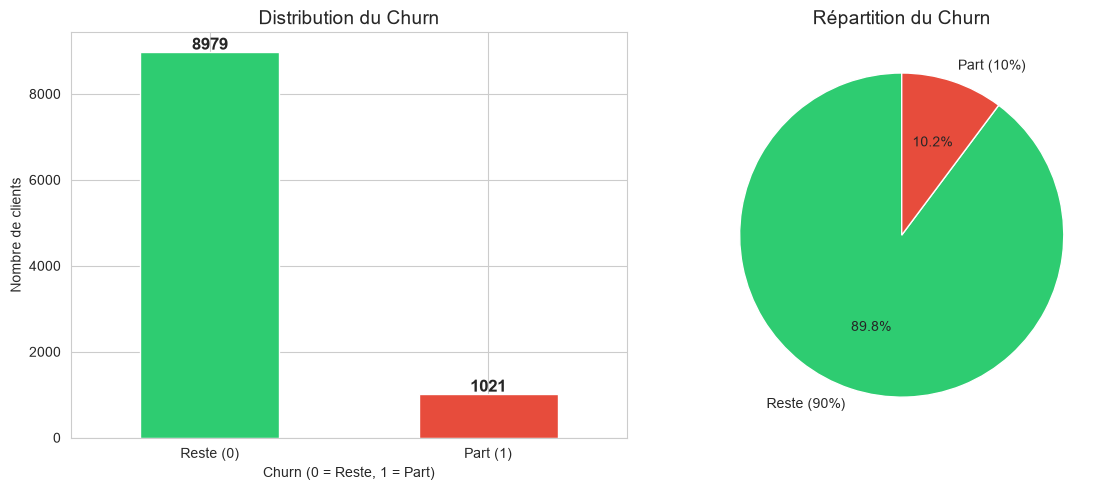

In [123]:
# On compte combien de clients ont churné (1) et combien sont restés (0)
print("=== DISTRIBUTION DU CHURN ===")
print(df['churn'].value_counts())
print(f"\nPourcentage de churners : {df['churn'].mean()*100:.1f}%")
print(f"Pourcentage de non-churners : {(1-df['churn'].mean())*100:.1f}%")

# On fait un graphique pour visualiser ça
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 : barres
df['churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution du Churn', fontsize=14)
axes[0].set_xlabel('Churn (0 = Reste, 1 = Part)')
axes[0].set_ylabel('Nombre de clients')
axes[0].set_xticklabels(['Reste (0)', 'Part (1)'], rotation=0)

# On ajoute les chiffres sur les barres
for i, v in enumerate(df['churn'].value_counts()):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12, fontweight='bold')

# Graphique 2 : camembert
df['churn'].value_counts().plot(kind='pie', ax=axes[1], 
                                 labels=['Reste (90%)', 'Part (10%)'],
                                 colors=['#2ecc71', '#e74c3c'],
                                 autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition du Churn', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Le dataset présente un déséquilibre significatif des classes avec 89.8% de non-churners contre 10.2% de churners, soit un ratio de déséquilibre de 8.8:1. Dans ce contexte, l'accuracy seule est une métrique trompeuse — un modèle qui prédirait systématiquement 'le client reste' obtiendrait 89.8% d'accuracy sans jamais détecter un seul churner. Nous privilégierons donc le Recall, le F1-score et le PR-AUC comme métriques principales

In [124]:
# Les types de variables
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

print(numerical_columns)

print(categorical_columns)

Index(['age', 'tenure_months', 'monthly_logins', 'weekly_active_days',
       'avg_session_time', 'features_used', 'usage_growth_rate',
       'last_login_days_ago', 'monthly_fee', 'total_revenue',
       'payment_failures', 'support_tickets', 'avg_resolution_time',
       'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate',
       'nps_score', 'referral_count', 'churn'],
      dtype='str')
Index(['customer_id', 'gender', 'country', 'city', 'customer_segment',
       'signup_channel', 'contract_type', 'payment_method', 'discount_applied',
       'price_increase_last_3m', 'complaint_type', 'survey_response'],
      dtype='str')


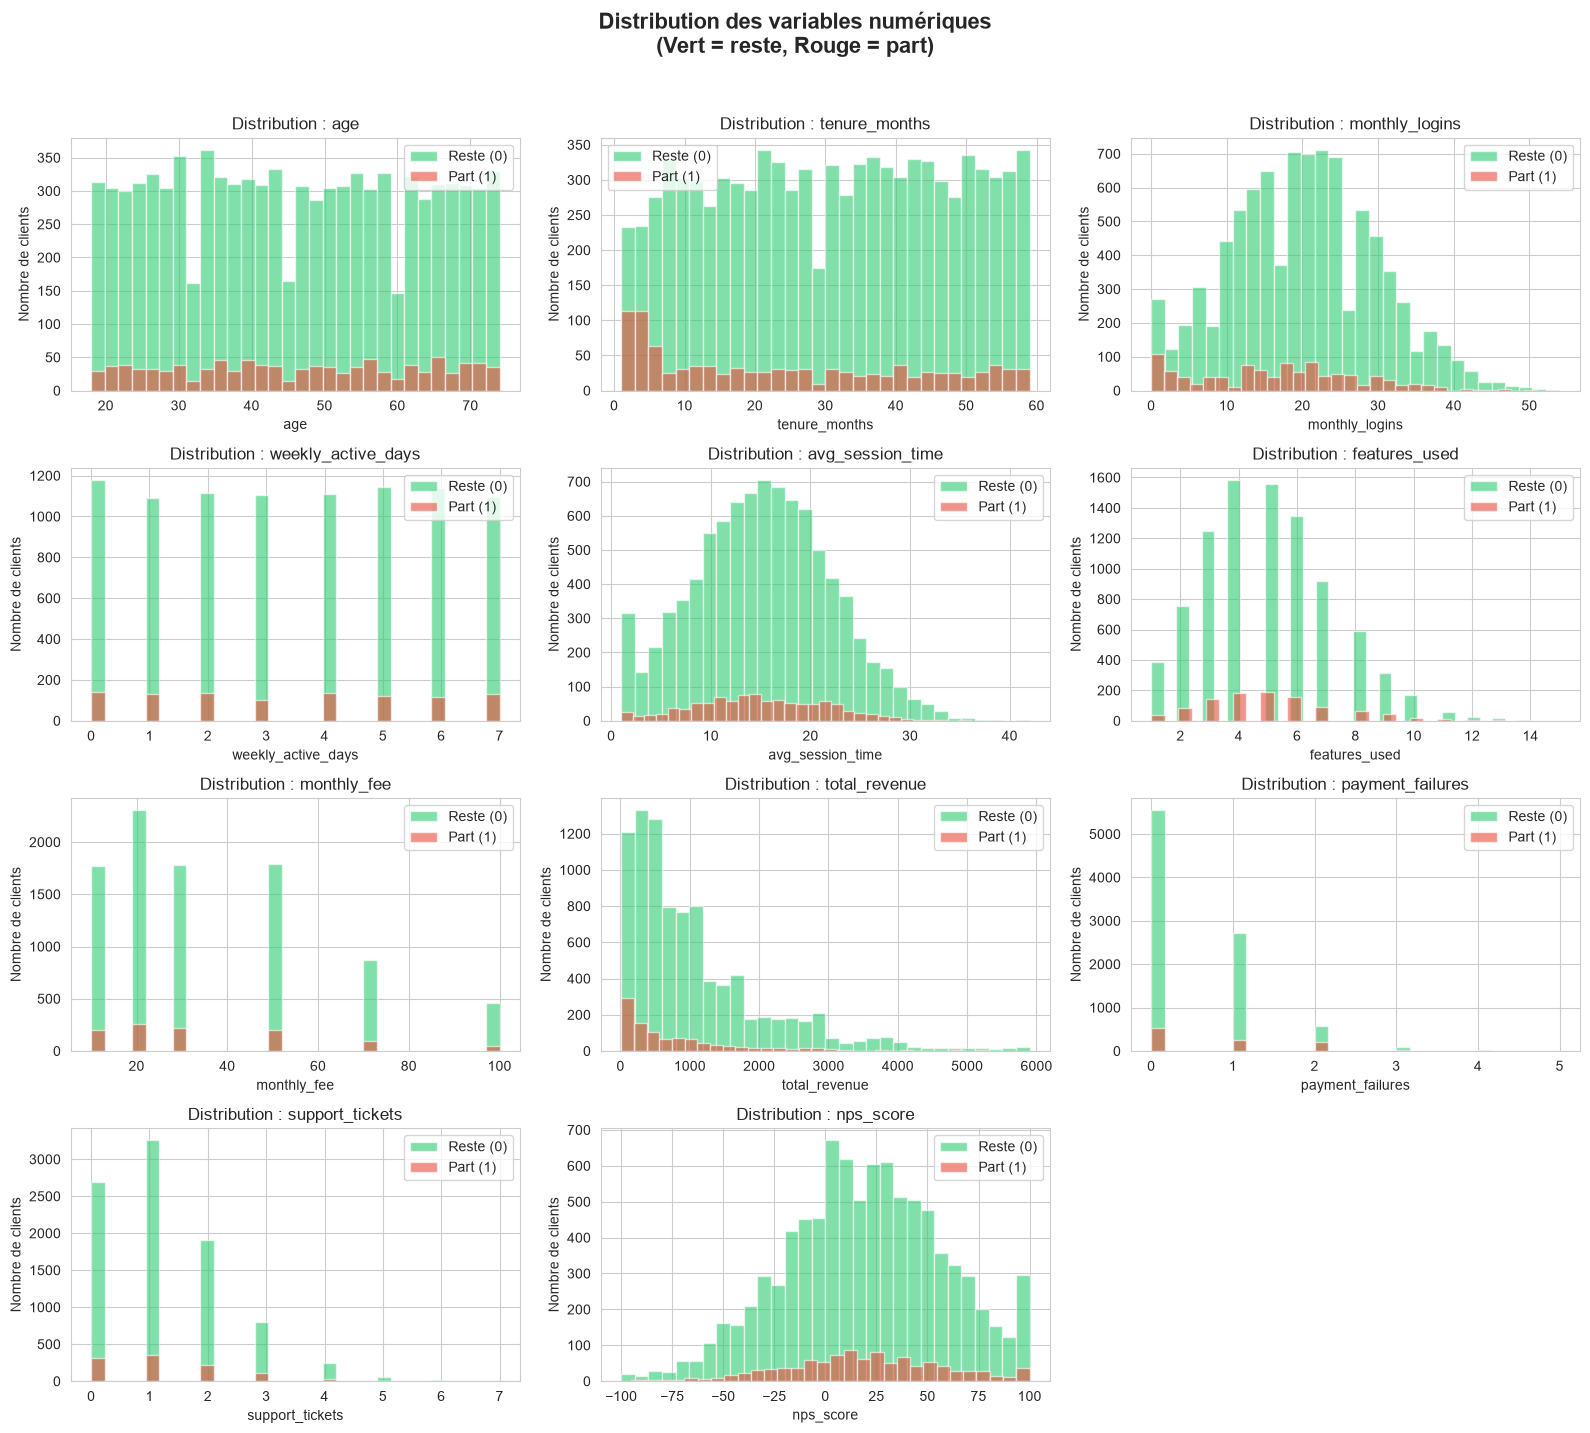

In [125]:
# On va regarder la distribution de chaque variable numérique
# Pour comprendre comment les données sont réparties
# On sélectionne les colonnes numériques les plus pertinentes
selected_numerical_columns = [
    'age',
    'tenure_months',
    'monthly_logins',
    'weekly_active_days',
    'avg_session_time',
    'features_used',
    'monthly_fee',
    'total_revenue',
    'payment_failures',
    'support_tickets',
    'nps_score'
]
# On crée une grille de graphiques (histogrammes)
# Un histogramme montre comment les valeurs sont réparties
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()  # On met tous les axes dans une liste simple

for i, col in enumerate(selected_numerical_columns):
    # On sépare les churners des non-churners pour comparer
    axes[i].hist(df[df['churn']==0][col], bins=30, 
                 alpha=0.6, color='#2ecc71', label='Reste (0)')
    axes[i].hist(df[df['churn']==1][col], bins=30, 
                 alpha=0.6, color='#e74c3c', label='Part (1)')
    axes[i].set_title(f'Distribution : {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre de clients')
    axes[i].legend()

# On cache le dernier graphique (vide)
axes[-1].set_visible(False)

plt.suptitle('Distribution des variables numériques\n(Vert = reste, Rouge = part)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


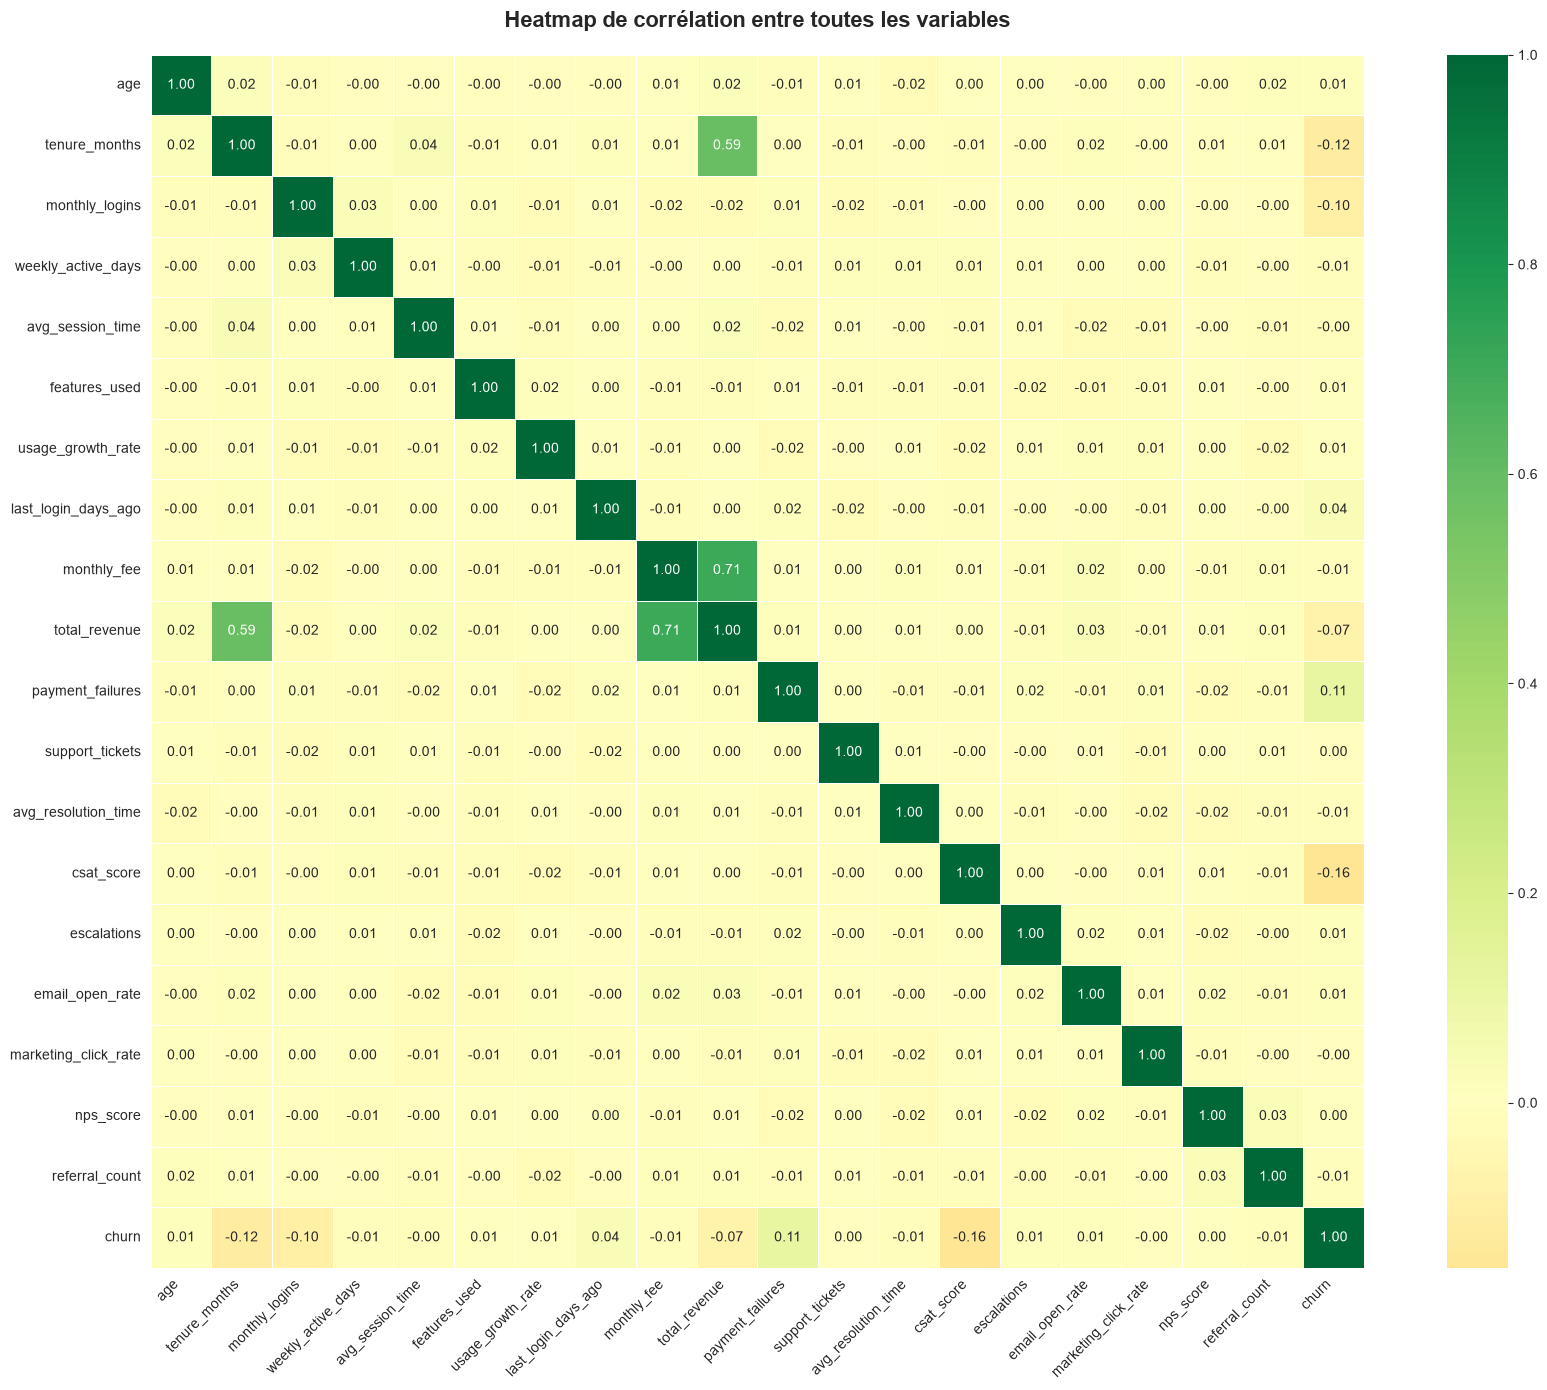

In [126]:
# Une heatmap de corrélation montre à quel point deux variables sont liées
# La corrélation va de -1 à +1 :
# +1 = quand une variable augmente, l'autre augmente aussi
# -1 = quand une variable augmente, l'autre diminue
#  0 = pas de lien entre les deux variables


# On calcule la corrélation entre toutes les variables
correlation = df[numerical_columns].corr()

# On crée la heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(correlation, 
            annot=True,          # Affiche les valeurs dans chaque case
            fmt='.2f',           # Arrondit à 2 décimales
            cmap='RdYlGn',       # Rouge = corrélation négative, Vert = positive
            center=0,            # Le centre de la couleur est à 0
            square=True,         # Cases carrées
            linewidths=0.5)      # Lignes entre les cases

plt.title('Heatmap de corrélation entre toutes les variables', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Les corrélations observées sont globalement faibles à modérées. Cela suggère qu'aucune variable prise isolément n'explique parfaitement le churn. L'utilisation d'algorithmes de Machine Learning permettra de combiner plusieurs variables afin de capturer des relations plus complexes.

csat_score             -0.157924
tenure_months          -0.117014
monthly_logins         -0.098339
total_revenue          -0.070120
avg_resolution_time    -0.009172
weekly_active_days     -0.008818
referral_count         -0.007323
monthly_fee            -0.005048
avg_session_time       -0.004659
marketing_click_rate   -0.002068
support_tickets         0.000317
nps_score               0.002996
usage_growth_rate       0.005276
features_used           0.005435
escalations             0.009561
age                     0.010155
email_open_rate         0.011506
last_login_days_ago     0.037250
payment_failures        0.112494
Name: churn, dtype: float64

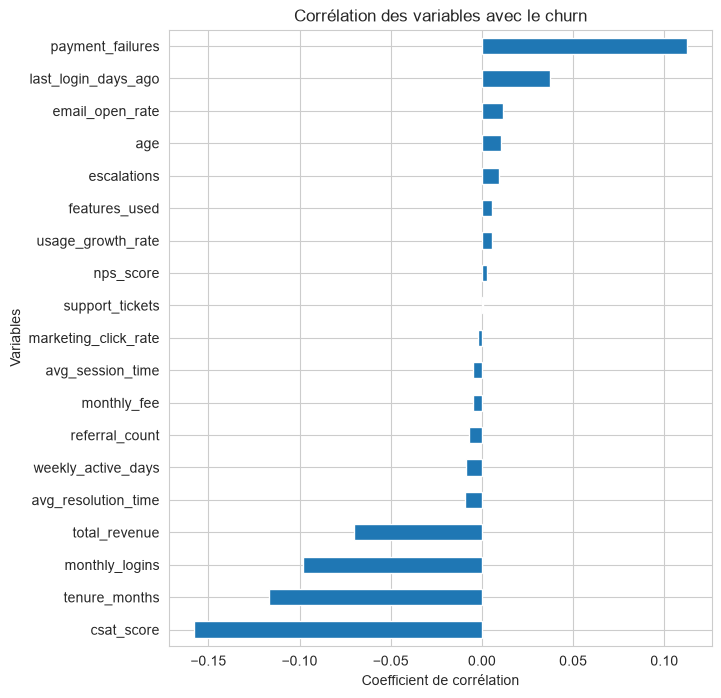

In [127]:
# Corrélation entre les variables numériques et le churn

corr = df.corr(numeric_only=True)

# On retire la corrélation du churn avec lui-même
corr_churn = corr["churn"].drop("churn").sort_values()

# Affichage des coefficients de corrélation
display(corr_churn)

# Visualisation graphique
corr_churn.plot.barh(figsize=(7, 8))

plt.title("Corrélation des variables avec le churn")
plt.xlabel("Coefficient de corrélation")
plt.ylabel("Variables")

plt.show()

### Analyse

Les coefficients de corrélation montrent quelles variables numériques sont les plus associées à la variable cible **churn**.

Les variables présentant une corrélation élevée (positive ou négative) sont susceptibles d'avoir une influence sur le comportement des clients. Cependant, une corrélation ne signifie pas nécessairement une relation de causalité. Ces résultats seront confirmés lors de la phase de modélisation.

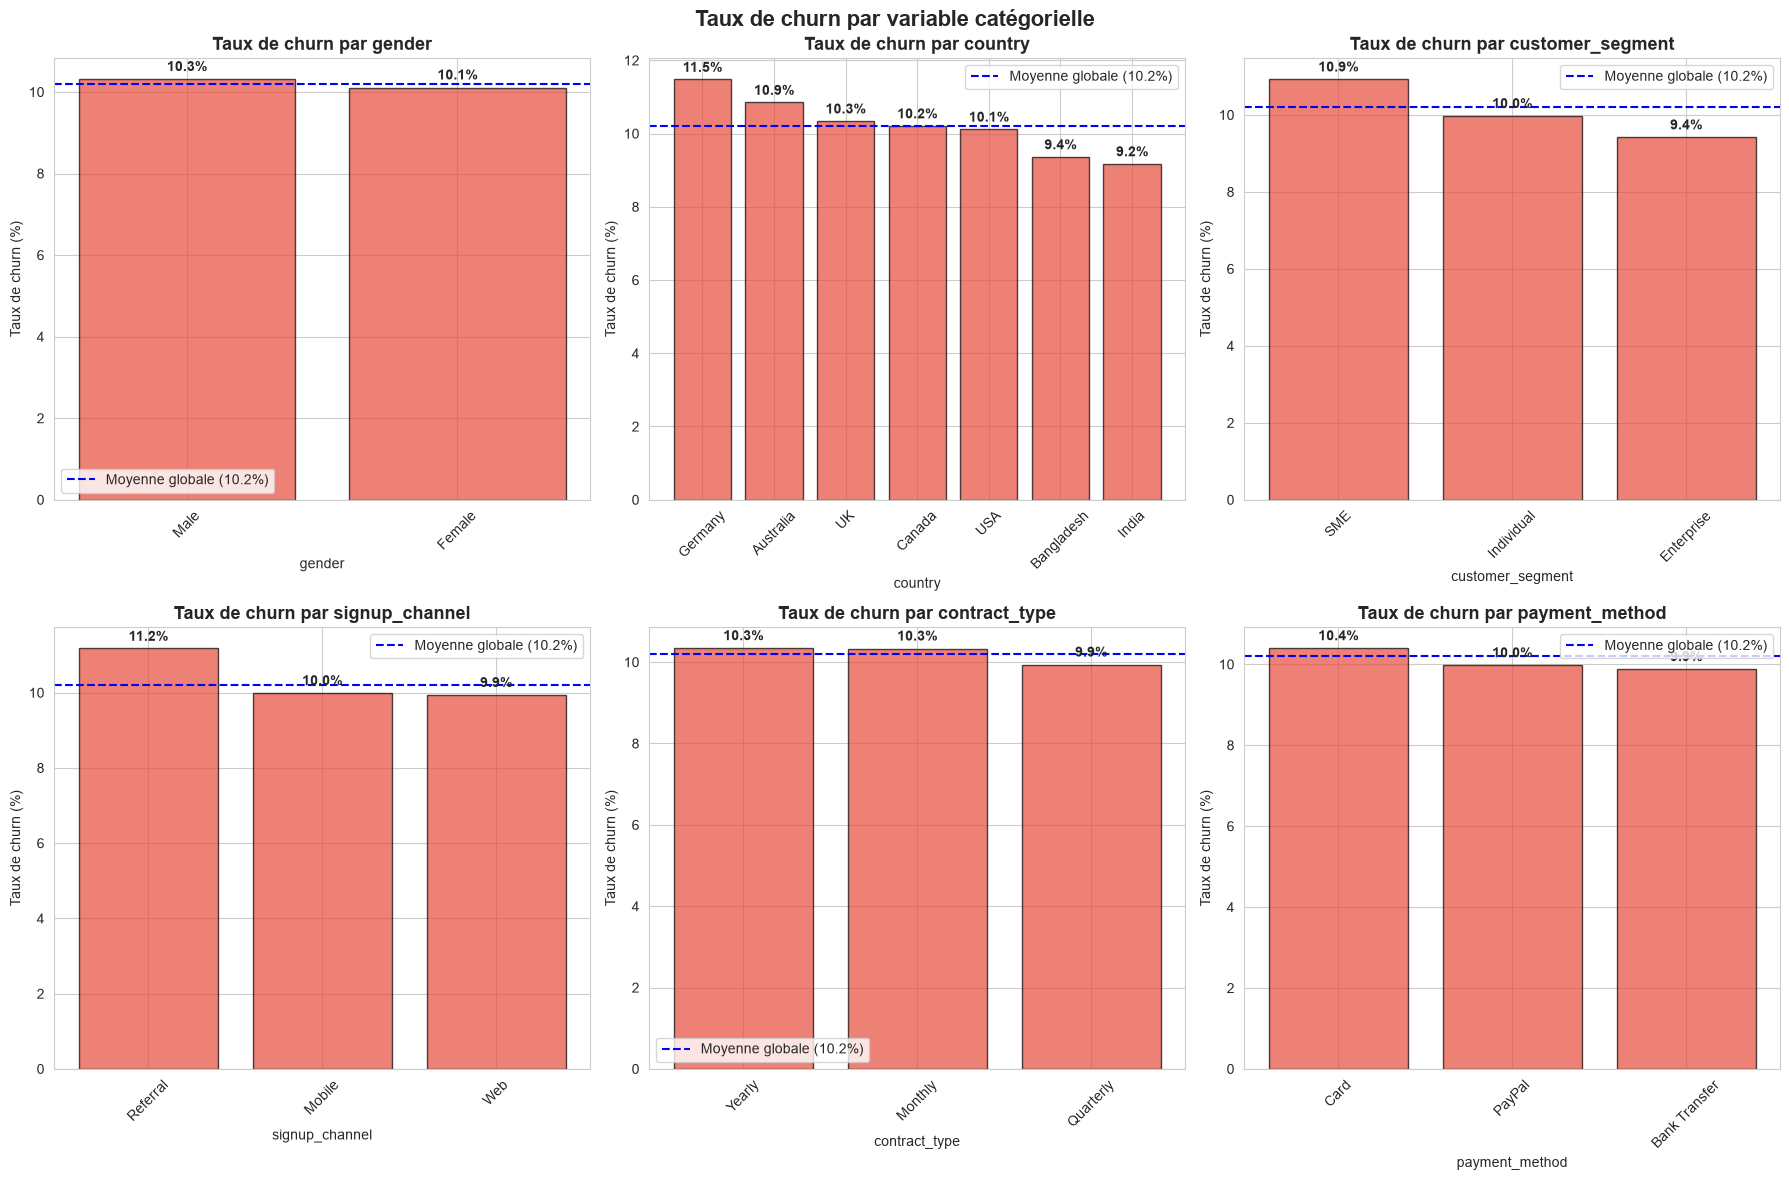

In [128]:
# Les variables catégorielles sont les colonnes texte
# On veut savoir : est-ce que le taux de churn varie selon le genre, 
# le type de contrat, le canal d'inscription etc. ?
selected_categorical_columns = ['gender', 'country', 'customer_segment', 
                           'signup_channel', 'contract_type', 'payment_method']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(selected_categorical_columns):
    # On calcule le taux de churn pour chaque catégorie
    # C'est à dire : parmi les hommes, combien % ont churné ?
    churn_rate = df.groupby(col)['churn'].mean() * 100
    
    # On trie par taux de churn décroissant
    churn_rate = churn_rate.sort_values(ascending=False)
    
    # On fait le graphique
    bars = axes[i].bar(churn_rate.index, churn_rate.values, 
                        color='#e74c3c', alpha=0.7, edgecolor='black')
    
    # On ajoute les pourcentages sur chaque barre
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                     bar.get_height() + 0.2,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    
    axes[i].set_title(f'Taux de churn par {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].tick_params(axis='x', rotation=45)
    
    # On ajoute une ligne pointillée à 10.2% (taux moyen global)
    axes[i].axhline(y=10.2, color='blue', linestyle='--', 
                     linewidth=1.5, label='Moyenne globale (10.2%)')
    axes[i].legend()

plt.suptitle('Taux de churn par variable catégorielle', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Toutes les variables catégorielles ont des taux de churn très proches de la moyenne (10.2%)

## Corrélation des variables catégorielles

Contrairement aux variables numériques, les variables catégorielles ne peuvent pas être comparées à l'aide du coefficient de corrélation de Pearson.

Nous utilisons ici :
- le test du Chi² pour vérifier l'existence d'une association entre deux variables catégorielles ;
- le coefficient V de Cramér pour mesurer l'intensité de cette association.

In [129]:
from scipy.stats import chi2_contingency
import numpy as np
# Test du Chi² entre le type de contrat et le churn

table = pd.crosstab(df["contract_type"], df["churn"])

chi2, p, dof, expected = chi2_contingency(table)

print(f"Statistique du Chi² : {chi2:.2f}")
print(f"P-value : {p:.5f}")

Statistique du Chi² : 0.36
P-value : 0.83374


La p-value étant largement supérieure à 0,05, aucune association statistiquement significative n'est observée entre le type de contrat et le churn dans ce jeu de données.

In [130]:
# Fonction de calcul du coefficient V de Cramér

def cramers_v(x, y):

    data = pd.DataFrame({
        "x": x,
        "y": y
    }).dropna()

    confusion_matrix = pd.crosstab(data["x"], data["y"])

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))

In [131]:
# Variables catégorielles utilisées

categorical_corr = [
    "gender",
    "country",
    "customer_segment",
    "signup_channel",
    "contract_type",
    "payment_method",
    "discount_applied",
    "price_increase_last_3m",
    "complaint_type",
    "survey_response"
]

In [132]:
# Association entre chaque variable catégorielle et le churn

cramers_target = {}

for col in categorical_corr:

    cramers_target[col] = cramers_v(
        df[col],
        df["churn"]
    )

cramers_target = pd.Series(cramers_target).sort_values(ascending=False)

display(cramers_target)

country                   0.024294
survey_response           0.016698
customer_segment          0.016508
signup_channel            0.016016
discount_applied          0.012844
payment_method            0.007459
contract_type             0.006031
complaint_type            0.004910
gender                    0.003087
price_increase_last_3m    0.002433
dtype: float64

Le coefficient V de Cramér permet de classer les variables catégorielles selon leur niveau d'association avec le churn.

Les variables présentant les coefficients les plus élevés seront particulièrement intéressantes lors de la modélisation.

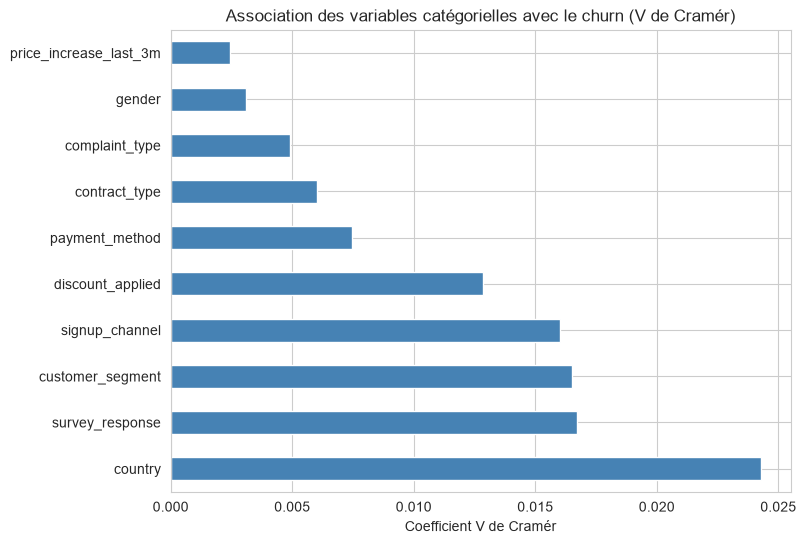

In [133]:
plt.figure(figsize=(8,6))

cramers_target.plot.barh(color="steelblue")

plt.title("Association des variables catégorielles avec le churn (V de Cramér)")

plt.xlabel("Coefficient V de Cramér")

plt.show()

In [134]:
# Construction de la matrice de V de Cramér

cramers_matrix = pd.DataFrame(
    index=categorical_corr,
    columns=categorical_corr,
    dtype=float
)

for col1 in categorical_corr:
    for col2 in categorical_corr:

        cramers_matrix.loc[col1, col2] = cramers_v(
            df[col1],
            df[col2]
        )

display(cramers_matrix.round(2))

,gender,country,customer_segment,signup_channel,contract_type,payment_method,discount_applied,price_increase_last_3m,complaint_type,survey_response
gender,1.00,0.02,0.02,0.01,0.01,0.02,0.00,0.01,0.01,0.02
country,0.02,1.00,0.02,0.02,0.02,0.02,0.02,0.03,0.03,0.02
customer_segment,0.02,0.02,1.00,0.01,0.02,0.01,0.03,0.01,0.01,0.01
signup_channel,0.01,0.02,0.01,1.00,0.01,0.02,0.01,0.01,0.01,0.01
contract_type,0.01,0.02,0.02,0.01,1.00,0.01,0.02,0.01,0.01,0.01
payment_method,0.02,0.02,0.01,0.02,0.01,1.00,0.02,0.01,0.02,0.02
discount_applied,0.00,0.02,0.03,0.01,0.02,0.02,1.00,0.01,0.01,0.01
price_increase_last_3m,0.01,0.03,0.01,0.01,0.01,0.01,0.01,1.00,0.02,0.02
complaint_type,0.01,0.03,0.01,0.01,0.01,0.02,0.01,0.02,1.00,0.01
survey_response,0.02,0.02,0.01,0.01,0.01,0.02,0.01,0.02,0.01,1.00


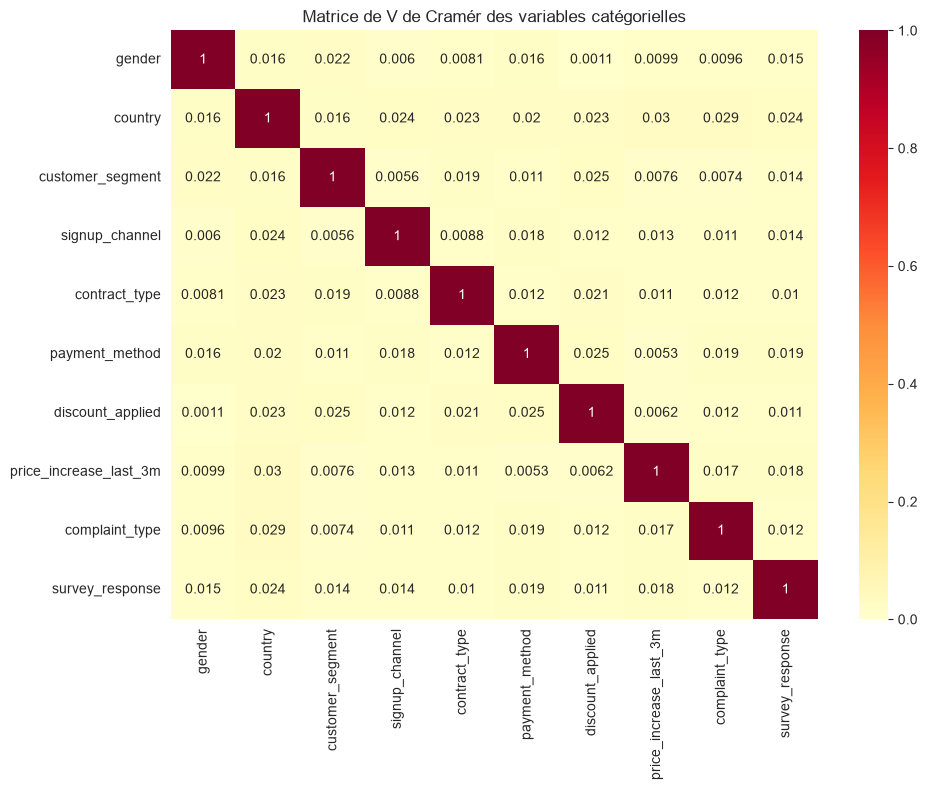

In [135]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="YlOrRd",
    vmin=0,
    vmax=1
)

plt.title("Matrice de V de Cramér des variables catégorielles")

plt.tight_layout()

plt.show()

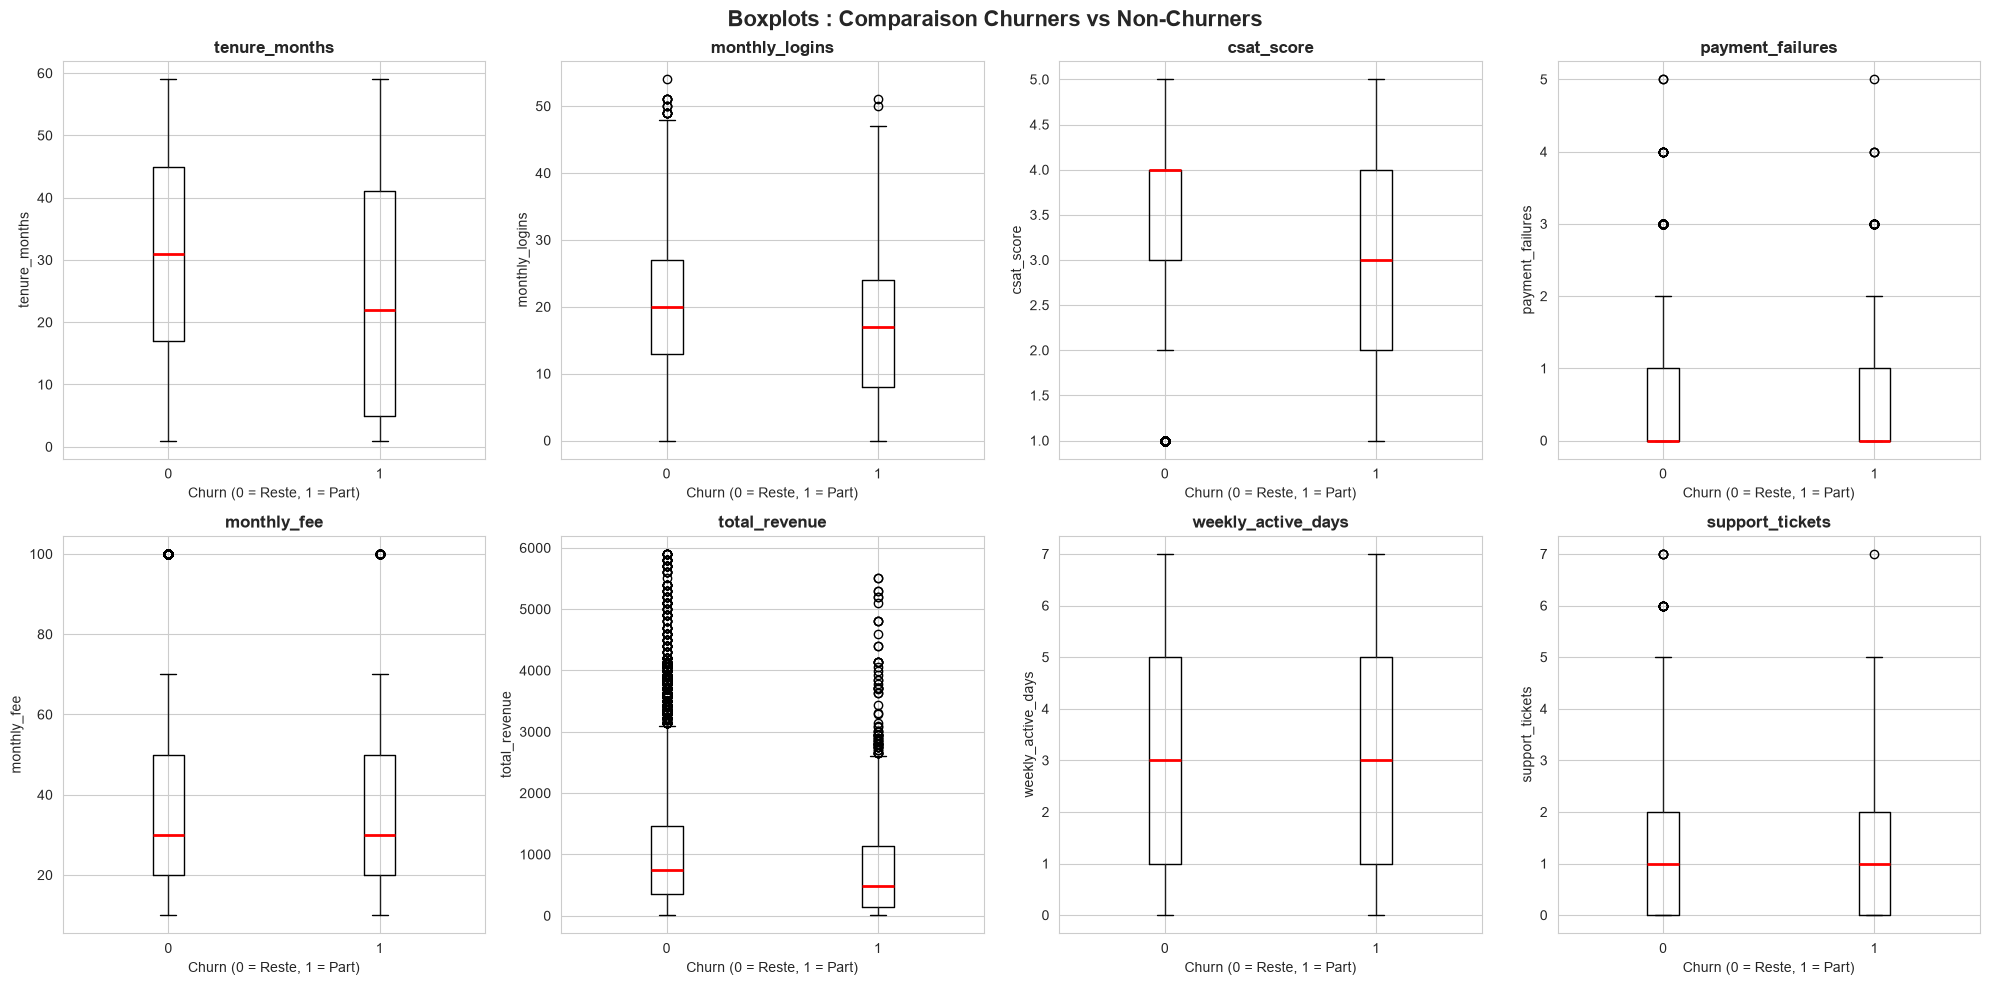

In [136]:
# Un boxplot montre la distribution d'une variable pour chaque groupe
# Il nous permet de comparer les churners vs non-churners plus précisément
# 
# Comment lire un boxplot :
# - La ligne du milieu = la médiane (valeur du milieu)
# - La boîte = 50% des clients (entre 25% et 75%)
# - Les moustaches = les valeurs min et max (hors outliers)
# - Les points = les outliers (valeurs extrêmes)

variables_cles = ['tenure_months', 'monthly_logins', 'csat_score',
                  'payment_failures', 'monthly_fee', 'total_revenue',
                  'weekly_active_days', 'support_tickets']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_cles):
    # On crée le boxplot en séparant churners et non-churners
    df.boxplot(column=col, by='churn', ax=axes[i],
               boxprops=dict(color='black'),
               medianprops=dict(color='red', linewidth=2))
    
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Churn (0 = Reste, 1 = Part)')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots : Comparaison Churners vs Non-Churners', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Les variables les plus importantes pour prédire le churn sont tenure_months, csat_score, total_revenue et monthly_logins. 

Les boxplots mettent en évidence quelques valeurs extrêmes. À ce stade, elles sont conservées car elles peuvent représenter des comportements réels des clients. Leur traitement éventuel sera étudié pendant le prétraitement.

## Principaux enseignements de l'EDA
- Le jeu de données contient des valeurs manquantes uniquement dans la colonne `complaint_type`, qui seront traitées lors du prétraitement.
- Aucun doublon n'a été détecté.
- Les classes sont déséquilibrées (environ 10 % de churn).
- Les variables numériques présentent quelques valeurs extrêmes, conservées pour le moment.
- Certaines variables, comme `tenure_months`, `csat_score`, `total_revenue` et `monthly_logins`, semblent liées au churn.
- Ces observations guideront les choix de prétraitement et de modélisation.

## Conclusion

Cette analyse exploratoire a permis :

- d'évaluer la qualité des données ;
- d'identifier les variables numériques et catégorielles importantes ;
- de détecter les valeurs manquantes et les valeurs extrêmes ;
- d'observer plusieurs facteurs susceptibles d'influencer le churn.

Ces résultats serviront de base au prétraitement des données, puis à l'entraînement et à l'évaluation des modèles de Machine Learning.